In [2]:
import platform
import sys

from importlib import metadata

def _v(dist_name: str) -> str:
    try:
        return metadata.version(dist_name)
    except metadata.PackageNotFoundError:
        return "NOT INSTALLED"


# --- Web server stack ---
print(f"fastapi             : {_v('fastapi')}")
print(f"uvicorn             : {_v('uvicorn')}")
print(f"python-multipart     : {_v('python-multipart')}")  # import name is 'multipart'

# --- Core ML/NLP ---
print(f"torch               : {_v('torch')}")
print(f"transformers        : {_v('transformers')}")
print(f"datasets            : {_v('datasets')}")
print(f"sentence-transformers: {_v('sentence-transformers')}")

# --- CSV / Topic modelling ---
print(f"numpy               : {_v('numpy')}")
print(f"pandas              : {_v('pandas')}")
print(f"bertopic            : {_v('bertopic')}")
print(f"scikit-learn        : {_v('scikit-learn')}")  # import name is 'sklearn'
print(f"umap-learn          : {_v('umap-learn')}")     # import name is 'umap'
print(f"hdbscan             : {_v('hdbscan')}")

# --- Visualisation / utils used in your library code ---
print(f"tqdm                : {_v('tqdm')}")
print(f"matplotlib          : {_v('matplotlib')}")
print(f"seaborn             : {_v('seaborn')}")
print(f"plotly              : {_v('plotly')}")

# Optional: quick runtime info
try:
    import torch
    print(f"cuda_available      : {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"cuda_device_name    : {torch.cuda.get_device_name(0)}")
except Exception:
    pass


fastapi             : 0.128.0
uvicorn             : 0.38.0
python-multipart     : 0.0.21
torch               : 2.8.0+cu126
transformers        : 4.57.1
datasets            : 4.4.1
sentence-transformers: 5.1.2
numpy               : 2.1.2
pandas              : 2.3.3
bertopic            : 0.17.4
scikit-learn        : 1.7.2
umap-learn          : 0.5.9.post2
hdbscan             : 0.8.41
tqdm                : 4.67.1
matplotlib          : 3.10.7
seaborn             : 0.13.2
plotly              : 6.4.0
cuda_available      : True
cuda_device_name    : NVIDIA GeForce RTX 4070 Laptop GPU


### 0. Preparation

In [ ]:
# ====== Complete BERT family framework (Custom library) ======
import SEDNA_BERT as bert

# ====== Basic utilities for data handling and visualization ======
import collections
import tqdm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ====== Core deep learning libraries (PyTorch) ======
import torch
import torch.nn as nn
import torch.optim as optim

# ====== Hugging Face ecosystem: data and pretrained models ======
import datasets
from datasets import load_dataset
import transformers
from transformers import AutoTokenizer

In [8]:
# Load the amazon_clean dataset
train_clean = load_dataset(
    "csv",
    data_files="/mnt/f/Warwick_Module/ST415/Code & Dependencies/train_clean.csv")["train"]

test_clean = load_dataset(
    "csv",
    data_files="/mnt/f/Warwick_Module/ST415/Code & Dependencies/test_clean.csv")["train"]

# Only need "label" & "title" & "text"
train_clean = train_clean.remove_columns(
    [col for col in train_clean.column_names if col not in ["label", "title" ,"text", "Class"]])

test_clean = test_clean.remove_columns(
    [col for col in test_clean.column_names if col not in ["label", "title" ,"text", "Class"]])

# Escape quotes in "text" so it is safe to embed into prompts
# Replace double quotes " with single quotes '
def escape_text_quotes(example):
    txt = example.get("text", "")
    if txt is None:
        txt = ""
    example["text"] = txt.replace('"', "'")
    return example

train_clean = train_clean.map(escape_text_quotes)
test_clean = test_clean.map(escape_text_quotes)


In [8]:
# train_clean = load_dataset(
    #"csv",
    #data_files="/mnt/f/Warwick Module/ST415/Code & Dependencies/train_clean.csv")["train"]

# train_clean = train_clean.remove_columns(
    #[col for col in train_clean.column_names if col not in ["text", "Gibberish_Score", "English_Ratio", "Perplexity", "Class"]])

# train_clean.to_pandas()

,text,Gibberish_Score,English_Ratio,Perplexity,Class
0,This sound track was beautiful! It paints the ...,4.916961,0.783784,120.147955,Meaningful
1,I'm reading a lot of reviews saying that this ...,0.813691,0.916667,31.164884,Meaningful
2,This soundtrack is my favorite music of all ti...,1.170734,0.849624,43.369774,Meaningful
3,I truly like this soundtrack and I enjoy video...,11.104782,0.825000,118.222136,Meaningful
4,"If you've played the game, you know how divine...",2.770231,0.835443,64.974230,Meaningful
...,...,...,...,...,...
1048564,"You can tell right away that this is a rugged,...",10.610584,0.906977,101.233935,Meaningful
1048565,If you have 1-4 power bricks and only one outl...,2.685576,0.954545,56.926959,Meaningful
1048566,Exactly what I was looking for at the office. ...,2.393140,0.833333,156.202565,Meaningful
1048567,"Just got a couple - very high quality, no comp...",22.814465,0.918919,171.222419,Meaningful


In [6]:
from transformers import AutoTokenizer
import numpy as np
import plotly.graph_objects as go


def check_token(dataset, tokenizer_dir_or_name, text_col="text", chunk_size=2048, bin_width=10):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir_or_name, use_fast=True, local_files_only=True)

    texts = dataset[text_col]
    texts = [("" if t is None else str(t)) for t in texts]

    token_lens = []
    for i in range(0, len(texts), chunk_size):
        enc = tokenizer(
            texts[i:i + chunk_size],
            add_special_tokens=False,
            padding=False,
            truncation=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )
        token_lens.extend([len(ids) for ids in enc["input_ids"]])

    token_lens = np.asarray(token_lens, dtype=np.int32)

    max_tok = int(token_lens.max())
    edges = np.arange(0, max_tok + bin_width + 1, bin_width, dtype=np.int32)
    counts, edges = np.histogram(token_lens, bins=edges)

    pct = counts / counts.sum() * 100.0
    left = edges[:-1]
    right = edges[1:]
    centres = (left + right) / 2.0

    fig = go.Figure(
        data=[
            go.Bar(
                x=centres,
                y=pct,
                customdata=np.column_stack([left, right, counts]),
                hovertemplate=(
                    "Bin: %{customdata[0]}–%{customdata[1]} tokens<br>"
                    "Count: %{customdata[2]}<br>"
                    "Percent: %{y:.3f}%<extra></extra>"
                ),
            )
        ]
    )

    fig.update_layout(
        title=f"Token histogram of '{text_col}' (bars sum to 100%)",
        xaxis_title="Token count (LLaMA tokenizer)",
        yaxis_title="Percent of reviews (%)",
        bargap=0.05,
        height=480,
        margin=dict(l=60, r=20, t=60, b=60),
    )

    fig.show()
    return token_lens


# Example
TOKENIZER_DIR = "/mnt/f/Programming/DS_ML_DL/Transformer/LLaMA_3/LLaMA_3_instruct_8B_4bits"
token_lens_train = check_token(test_clean, TOKENIZER_DIR, text_col="text", chunk_size=2048, bin_width=10)


#### 抽样

In [3]:
import os

# -----------------------
# 1) Shuffle + uniform 5% sampling (every 20th)
# -----------------------
train_shuf = train_clean.shuffle(seed=2201370)

n_total = len(train_shuf)
step = 1000
idx = list(range(0, n_total, step))

train_batch = train_shuf.select(idx)

# -----------------------
# 2) Export to CSV on Windows Desktop via /mnt/c
# -----------------------
out_dir = "/mnt/c/Users/Levizenith/Desktop"
out_path = os.path.join(out_dir, "train_batch_5pct_uniform.csv")

os.makedirs(out_dir, exist_ok=True)

# Convert to pandas then save
df = train_batch.to_pandas()
df.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"Saved CSV to: {out_path}")
print(f"Rows saved: {len(df)}")


Saved CSV to: /mnt/c/Users/Levizenith/Desktop/train_batch_5pct_uniform.csv
Rows saved: 1049


In [4]:
train_batch

Dataset({
    features: ['label', 'title', 'text', 'Class'],
    num_rows: 2098
})

In [6]:
# Parameter summary
import re
from collections import defaultdict

def summarize_parameters_clean(model):
    """
    Clean and compact parameter summary for Sentiment_Analysis model.
    Removes redundant prefixes and subpaths, groups encoder layers,
    and appends total parameter count.
    """

    summary = defaultdict(lambda: {"shape": None, "per_layer": 0, "layers": 0, "total": 0})
    total_params = 0

    for name, param in model.named_parameters():
        clean_name = name

        # === 1️. Remove redundant prefixes ===
        clean_name = clean_name.replace("selected_transformer.", "")

        # === 2️. Simplify layer names ===
        clean_name = re.sub(r"\.self\.", ".", clean_name)
        clean_name = re.sub(r"\.output\.", ".", clean_name)
        clean_name = re.sub(r"encoder\.layer\.\d+", "encoder.encoder", clean_name)

        # === 3. Clean up .layer.N ===
        clean_name = clean_name.replace(".encoder.", ".")

        # === 4️. Record shape and counts ===
        shape = tuple(param.shape)
        if len(shape) == 1:
            shape = (shape[0], 1)

        count = param.numel()
        total_params += count

        if summary[clean_name]["shape"] is None:
            summary[clean_name]["shape"] = shape
            summary[clean_name]["per_layer"] = count

        summary[clean_name]["layers"] += 1
        summary[clean_name]["total"] += count

    # --- Print Header ---
    print("\n=== Parameter Summary (Compact) ===")
    header = f"{'Layer / Parameter':40} | {'Shape':15} | {'Per-layer':>12} | {'#Layers':>8} | {'Total':>12}"
    print(header)
    print("-" * len(header))

    # --- Print Each Row ---
    for k, v in summary.items():
        name = k
        shape = str(v["shape"])
        per_layer = f"{v['per_layer']:,}" if v['layers'] > 1 else "-"
        layers = f"{v['layers']}" if v['layers'] > 1 else "-"
        total = f"{v['total']:,}"
        print(f"{name:40} | {shape:15} | {per_layer:>12} | {layers:>8} | {total:>12}")

    # --- Final total line ---
    print("-" * len(header))
    print(f"{'Total Parameters':40} | {'-':15} | {'-':>12} | {'-':>8} | {total_params:>12,}")

In [ ]:
# =============================================================================================

### 1. Small Batch test

In [3]:
# ======== Small Batch test ========

In [3]:
sample_size = int(0.0005 * len(train_clean))

# batched train & test set
amazon_clean_batch = train_clean.shuffle(seed=222).select(range(sample_size))
amazon_clean_batch_test = train_clean.shuffle(seed=333).select(range(sample_size))

In [4]:
# Tokenization
train_data, test_data, tokenizer = bert.Apply_Tokenization(
    training_set = amazon_clean_batch,
    testing_set = amazon_clean_batch_test,
    tokenizer = "microsoft/deberta-v3-base")


# Split a validation set from the training set, then load all 3 datasets
train_data_loader, valid_data_loader, test_data_loader = bert.Train_Validate_Test_Loader(
    training_set = train_data,
    testing_set = test_data,
    validation_size = 0.25,
    batch_size = 8)

/home/levizenith/miniconda3/envs/SEDNA/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Training set tokenized. New features: dict_keys(['label', 'title', 'text', 'ids'])


Map:   0%|          | 0/524 [00:00<?, ? examples/s]

✅ Testing set tokenized. New features: dict_keys(['label', 'title', 'text', 'ids'])


In [5]:
# Load the base model, set 3 categories (positive, negative, gibberish), train ALL parameters
Sentiment_Model = bert.Sentiment_Analysis(
    selected_transformer = "microsoft/deberta-v3-base",
    category_num = 3, 
    freeze_base_model_param = False)


# Define the AdamW optimizer
optimizer, Loss_function, device = bert.X_Entropy_Hypersetting(
    Sentiment_Model = Sentiment_Model,
    lr = 1e-5,
    optimizer_selected = "adamw",
    device = "cuda")

Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu126 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [6]:
# Strat training
metrics = bert.Training_loop(
    epoch_num = 1,
    save_dir = "/mnt/f/Warwick Module/ST415/Code & Dependencies/test.pt")

Validating in progress...: 100%|██████████| 17/17 [00:01<00:00, 14.92it/s]


epoch: 0
train_loss: 0.818, train_acc: 0.593
valid_loss: 0.565, valid_acc: 0.890
✅ Model saved to: /mnt/f/Warwick Module/ST415/Code & Dependencies/test.pt


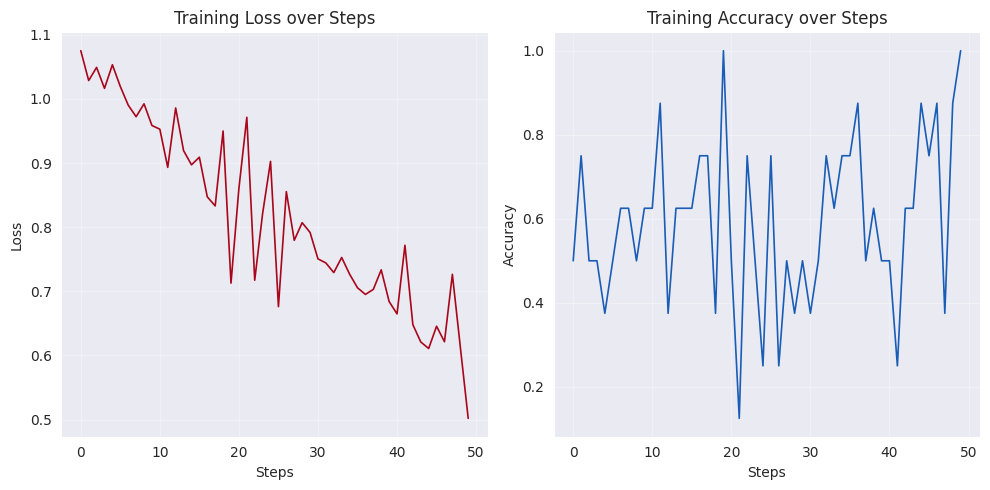

In [7]:
bert.Visualisation()

In [18]:
# Reload the saved model above
Reload_BERT = bert.Reload_Model(
    base_model = "microsoft/deberta-v3-base",
    model_dir = "/mnt/f/Warwick Module/ST415/Code & Dependencies/test.pt",
    device_selected = "cuda")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/f/Warwick Module/ST415/Code & Dependencies/test.pt'

In [9]:
# Test the model on the test set
bert.Test_model(Model=Reload_BERT, Label_mapping={0: "Negative", 1: "Positive", 2: "Gibberish"})

Validating in progress...: 100%|██████████| 66/66 [00:05<00:00, 12.31it/s]


,Label,Test_Loss,Test_Acc,Precision,Recall,F1
0,Negative,0.281,0.985,0.714,0.985,0.828
1,Positive,0.763,0.608,0.976,0.608,0.749
2,Weighted_Total,0.521,0.797,0.845,0.796,0.788


/home/levizenith/miniconda3/envs/SEDNA/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


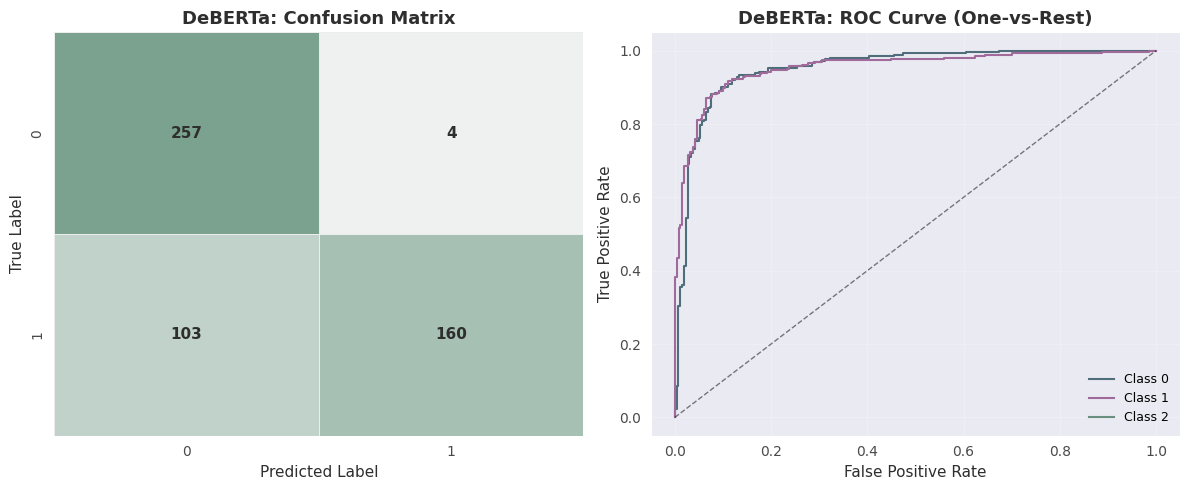

In [10]:
bert.Confusion_matrix_ROC(Model_Name = "DeBERTa")

In [11]:
bert.Misclassification(Label_mapping = {0: "Negative", 1: "Positive", 2: "Gibberish"})

,Index,True_label,Model_label,Confidence,Text
0,1,Positive,Negative,0.536,"No,no,no!! Flimsy, ticky tacky waste of money...."
1,2,Positive,Negative,0.516,This Taylor-Made support bar is sold by everyo...
2,3,Positive,Negative,0.825,this is the intro to b&s. something here for e...
3,4,Positive,Negative,0.578,"For a compilation cd, I must say it is wonderf..."
4,5,Positive,Negative,0.728,The sizing of this costume was fairly accurate...
...,...,...,...,...,...
102,103,Positive,Negative,0.493,"when i received this item, I quickly opened it..."
103,104,Positive,Negative,0.506,The first Ryan Adams Alt county album. I can r...
104,105,Positive,Negative,0.704,Having seen Lennart Nielsen's book a few years...
105,106,Positive,Negative,0.494,"I honestly recommend this book, it is helping ..."


In [12]:
# Test the Model
bert.Sentiment_Classification(
    text="I like this product, definitely recommend it!",
    BERT_Model=Reload_BERT,
    Label_mapping={0:"Negative", 1:"Positive", 2:"Gibberish"}
)

✨ Final Prediction: Positive  |  Confidence = 0.536


In [ ]:
# =============================================================================================

### 2. DeBERTa

In [ ]:
# ======== Whole amazon dataset (DeBERTa) ========

In [5]:
# Tokenization
train_data, test_data, tokenizer = bert.Apply_Tokenization(
    training_set = train_clean,
    testing_set = test_clean,
    tokenizer = "microsoft/deberta-v3-base")

/home/levizenith/miniconda3/envs/SEDNA/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


✅ Training set tokenized. New features: dict_keys(['label', 'title', 'text', 'Class', 'ids'])
✅ Testing set tokenized. New features: dict_keys(['label', 'title', 'text', 'Class', 'ids'])


In [6]:
# Split a validation set from the training set, then load all 3 datasets
train_data_loader, valid_data_loader, test_data_loader = bert.Train_Validate_Test_Loader(
    training_set = train_data,
    testing_set = test_data,
    validation_size = 0.25,
    batch_size = 8)

In [7]:
# Load the base model, set 3 categories (positive, negative, gibberish), train ALL parameters
Sentiment_Model = bert.Sentiment_Analysis(
    selected_transformer = "microsoft/deberta-v3-base",
    category_num = 3, 
    freeze_base_model_param = False)

Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu126 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


In [8]:
# Define the AdamW optimizer
optimizer, Loss_function, device = bert.X_Entropy_Hypersetting(
    Sentiment_Model = Sentiment_Model,
    lr = 1e-5,
    optimizer_selected = "adamw",
    device = "cuda")

In [7]:
# Strat training
metrics = bert.Training_loop(
    epoch_num = 1,
    save_dir = "/mnt/f/Warwick_Module/ST415/Code & Dependencies/DeBERTa_Sentiment_Analysis.pt")

Validating in progress...: 100%|██████████| 32768/32768 [32:01<00:00, 17.05it/s] 


epoch: 0
train_loss: 0.112, train_acc: 0.961
valid_loss: 0.108, valid_acc: 0.964
✅ Model saved to: /mnt/f/Warwick Module/ST415/Code & Dependencies/DeBERTa_Sentiment_Analysis.pt


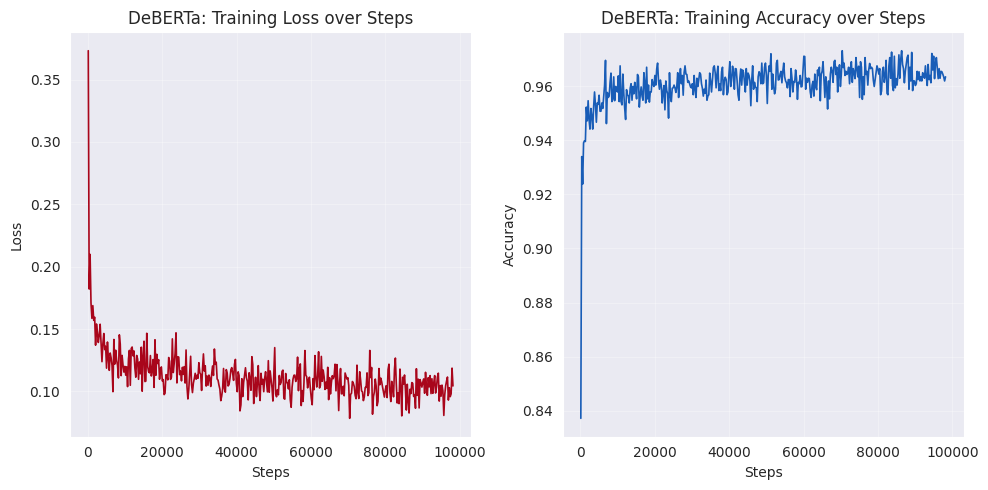

In [23]:
bert.Visualisation(Model_Name = "DeBERTa")

In [9]:
# Reload the saved model above
Reload_BERT = bert.Reload_Model(
    base_model = "microsoft/deberta-v3-base",
    model_dir = "/mnt/f/Warwick_Module/ST415/Code & Dependencies/DeBERTa_Sentiment_Analysis.pt",
    device_selected = "cuda")

Reloaded model: Reload_BERT has been loaded


In [15]:
# Test the model on the test set
bert.Test_model(Model=Reload_BERT, Label_mapping={0: "Negative", 1: "Positive", 2: "Gibberish"})

Validating in progress...: 100%|██████████| 50000/50000 [38:39<00:00, 21.56it/s]


,Label,Test_Loss,Test_Acc,Precision,Recall,F1
0,Negative,0.073,0.978,0.952,0.978,0.965
1,Positive,0.137,0.951,0.977,0.951,0.964
2,Gibberish,0.568,0.859,0.870,0.859,0.865
3,Weighted_Total,0.106,0.964,0.965,0.964,0.964


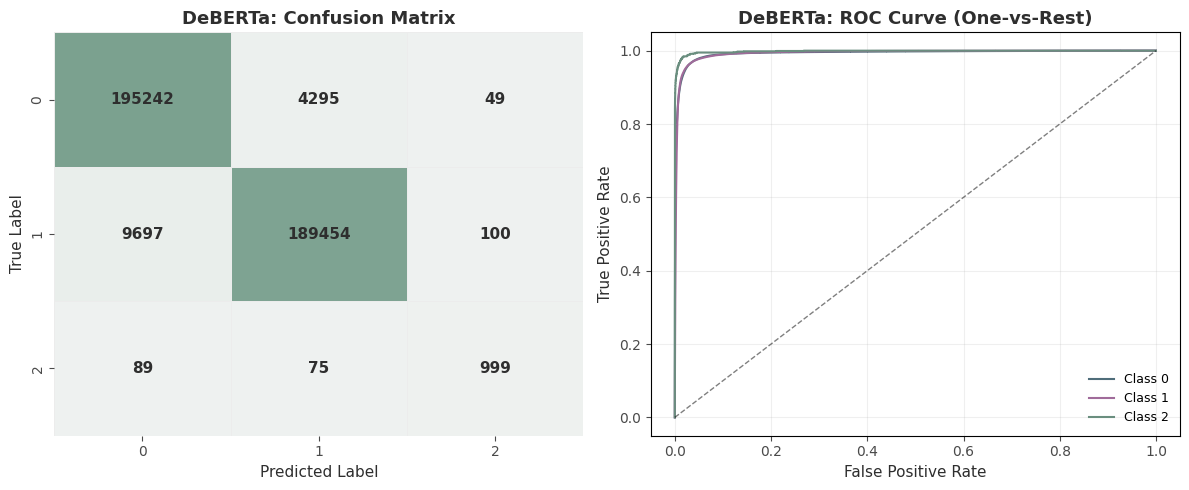

In [16]:
# Confusion matrix and ROC
bert.Confusion_matrix_ROC(Model_Name = "DeBERTa")

In [20]:
# Miclassification samples
bert.Misclassification(Label_mapping = {0: "Negative", 1: "Positive", 2: "Gibberish"})

RuntimeError: ❌ 'test_misclassified_samples' not found. Please run Test_model() first.

In [9]:
# Reload the saved model above
Reload_BERT = bert.Reload_Model(
    base_model = "microsoft/deberta-v3-base",
    model_dir = "/mnt/f/Warwick_Module/ST415/Code & Dependencies/DeBERTa_Sentiment_Analysis.pt",
    device_selected = "cuda")

Reloaded model: Reload_BERT has been loaded


In [10]:
# Test the Model
bert.Sentiment_Classification(
    text="I am an Australian and my parents are New Zealanders. They sent me one of these for my first child, she is now 2 and still lies on it in her bed and stroller. Then I ordered myself another one for my son now 6 months old. I live in the US now and order them for any friend having a baby. I simply throw mine in the washing machine and then fluff air dry it.I HIGHLY recommend this.",
    BERT_Model=Reload_BERT,
    Label_mapping={0:"Negative", 1:"Positive", 2:"Gibberish"})

✨ Final Prediction: Positive  |  Confidence = 0.998


('Positive', 0.998)

In [8]:
summarize_parameters_clean(Sentiment_Model)


=== Parameter Summary (Compact) ===
Layer / Parameter                        | Shape           |    Per-layer |  #Layers |        Total
---------------------------------------------------------------------------------------------------
embeddings.word_embeddings.weight        | (128100, 768)   |            - |        - |   98,380,800
embeddings.LayerNorm.weight              | (768, 1)        |            - |        - |          768
embeddings.LayerNorm.bias                | (768, 1)        |            - |        - |          768
encoder.attention.query_proj.weight      | (768, 768)      |      589,824 |       12 |    7,077,888
encoder.attention.query_proj.bias        | (768, 1)        |          768 |       12 |        9,216
encoder.attention.key_proj.weight        | (768, 768)      |      589,824 |       12 |    7,077,888
encoder.attention.key_proj.bias          | (768, 1)        |          768 |       12 |        9,216
encoder.attention.value_proj.weight      | (768, 768)      |   

In [ ]:
# =============================================================================================

### 3. RoBERTa

In [ ]:
# ======== Whole amazon dataset (RoBERTa) ========

In [3]:
# Tokenization
train_data, test_data, tokenizer = bert.Apply_Tokenization(
    training_set = train_clean,
    testing_set = test_clean,
    tokenizer = "roberta-base")

✅ Training set tokenized. New features: dict_keys(['label', 'title', 'text', 'ids'])
✅ Testing set tokenized. New features: dict_keys(['label', 'title', 'text', 'ids'])


In [4]:
# Split a validation set from the training set, then load all 3 datasets
train_data_loader, valid_data_loader, test_data_loader = bert.Train_Validate_Test_Loader(
    training_set = train_data,
    testing_set = test_data,
    validation_size = 0.25,
    batch_size = 8)

In [9]:
# Load the base model, set 3 categories (positive, negative, gibberish), train ALL parameters
Sentiment_Model = bert.Sentiment_Analysis(
    selected_transformer = "roberta-base",
    category_num = 3, 
    freeze_base_model_param = False)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Define the AdamW optimizer
optimizer, Loss_function, device = bert.X_Entropy_Hypersetting(
    Sentiment_Model = Sentiment_Model,
    lr = 1e-5,
    optimizer_selected = "adamw",
    device = "cuda")

In [15]:
# Strat training
metrics = bert.Training_loop(
    epoch_num = 1,
    save_dir = "/mnt/f/Warwick Module/ST415/Code & Dependencies/RoBERTa_Sentiment_Analysis.pt")

Validating in progress...: 100%|██████████| 32768/32768 [2:15:57<00:00,  4.02it/s]  


epoch: 0
train_loss: 0.128, train_acc: 0.955
valid_loss: 0.111, valid_acc: 0.961
✅ Model saved to: /mnt/f/Warwick Module/ST415/Code & Dependencies/RoBERTa_Sentiment_Analysis.pt


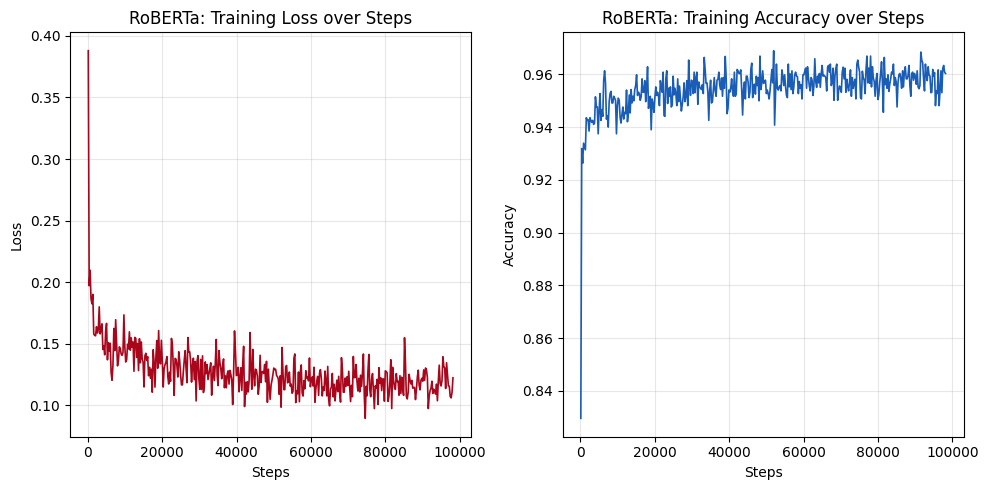

In [17]:
bert.Visualisation(Model_Name = "RoBERTa")

In [7]:
# Reload the saved model above
Reload_BERT = bert.Reload_Model(
    base_model = "roberta-base",
    model_dir = "/mnt/f/Warwick Module/ST415/Code & Dependencies/RoBERTa_Sentiment_Analysis.pt",
    device_selected = "cuda")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Reloaded model: Reload_BERT has been loaded


In [8]:
# Test the model on the test set
bert.Test_model(Model=Reload_BERT, Label_mapping={0: "Negative", 1: "Positive", 2: "Gibberish"})

Validating in progress...: 100%|██████████| 50000/50000 [26:03<00:00, 31.97it/s]


,Label,Test_Loss,Test_Acc,Precision,Recall,F1
0,Negative,0.100,0.970,0.953,0.970,0.962
1,Positive,0.118,0.953,0.969,0.953,0.961
2,Gibberish,0.594,0.847,0.900,0.847,0.873
3,Weighted_Total,0.110,0.961,0.961,0.961,0.961


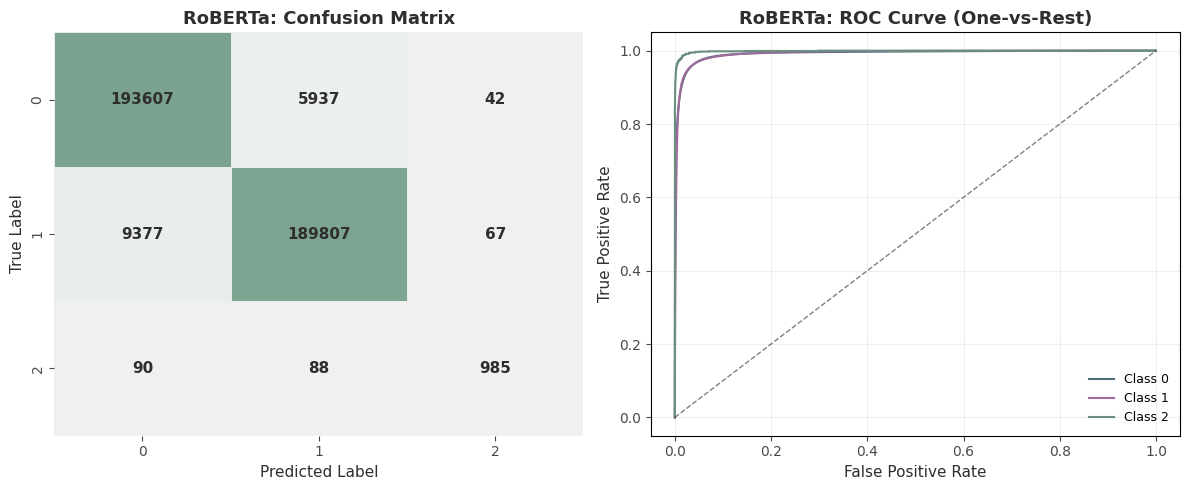

In [9]:
bert.Confusion_matrix_ROC(Model_Name = "RoBERTa")

In [10]:
bert.Misclassification(Label_mapping = {0: "Negative", 1: "Positive", 2: "Gibberish"})

,Index,True_label,Model_label,Confidence,Text
0,1,Negative,Positive,0.994,This game requires quicktime 5.0 to work..if y...
1,2,Negative,Positive,0.690,"Like many of the Barbie CD Roms, the playtime ..."
2,3,Negative,Positive,0.969,Very disappointed in this product. It worked p...
3,4,Negative,Positive,0.727,I was sorely disappointed in this vapid and sm...
4,5,Negative,Positive,0.849,god!! what a dumb movie. the fact that Adam Sa...
...,...,...,...,...,...
15596,15597,Positive,Negative,0.693,"With all the bad reviews,You might think this ..."
15597,15598,Negative,Positive,0.833,No DVD!! The case was shrink wrapped and opene...
15598,15599,Positive,Negative,0.729,This table is easy to put together and just wh...
15599,15600,Positive,Negative,0.894,There is way too much talking and detailed exp...


In [19]:
# Test the Model
bert.Sentiment_Classification(
    text="apple like it, recommend",
    BERT_Model=Reload_BERT,
    Label_mapping={0:"Negative", 1:"Positive", 2:"Gibberish"})

✨ Final Prediction: Positive  |  Confidence = 0.726


In [10]:
summarize_parameters_clean(Sentiment_Model)


=== Parameter Summary (Compact) ===
Layer / Parameter                        | Shape           |    Per-layer |  #Layers |        Total
---------------------------------------------------------------------------------------------------
embeddings.word_embeddings.weight        | (50265, 768)    |            - |        - |   38,603,520
embeddings.position_embeddings.weight    | (514, 768)      |            - |        - |      394,752
embeddings.token_type_embeddings.weight  | (1, 768)        |            - |        - |          768
embeddings.LayerNorm.weight              | (768, 1)        |            - |        - |          768
embeddings.LayerNorm.bias                | (768, 1)        |            - |        - |          768
encoder.attention.query.weight           | (768, 768)      |      589,824 |       12 |    7,077,888
encoder.attention.query.bias             | (768, 1)        |          768 |       12 |        9,216
encoder.attention.key.weight             | (768, 768)      |   

In [ ]:
# =============================================================================================

### 4. BERT

In [ ]:
# ======== Whole amazon dataset (BERT) ========

In [3]:
# Tokenization
train_data, test_data, tokenizer = bert.Apply_Tokenization(
    training_set=train_clean,
    testing_set=test_clean,
    tokenizer="bert-base-uncased")
# Split a validation set from the training set, then load all 3 datasets
train_data_loader, valid_data_loader, test_data_loader = bert.Train_Validate_Test_Loader(
    training_set=train_data,
    testing_set=test_data,
    validation_size=0.25,
    batch_size=8)

✅ Training set tokenized. New features: dict_keys(['label', 'title', 'text', 'ids'])


Map:   0%|          | 0/400000 [00:00<?, ? examples/s]

✅ Testing set tokenized. New features: dict_keys(['label', 'title', 'text', 'ids'])


In [11]:
# Load the base model, set 3 categories (positive, negative, gibberish), train ALL parameters
Sentiment_Model = bert.Sentiment_Analysis(
    selected_transformer="bert-base-uncased",
    category_num=3,
    freeze_base_model_param=False)
# Define the AdamW optimizer
optimizer, Loss_function, device = bert.X_Entropy_Hypersetting(
    Sentiment_Model=Sentiment_Model,
    lr=1e-5,
    optimizer_selected="adamw",
    device="cuda")

In [7]:
# Strat training
metrics = bert.Training_loop(
    epoch_num=1,
    save_dir="/mnt/f/Warwick Module/ST415/Code & Dependencies/BERT_Sentiment_Analysis.pt")


Validating in progress...: 100%|██████████| 32768/32768 [30:32<00:00, 17.88it/s]


epoch: 0
train_loss: 0.138, train_acc: 0.950
valid_loss: 0.120, valid_acc: 0.957
✅ Model saved to: /mnt/f/Warwick Module/ST415/Code & Dependencies/BERT_Sentiment_Analysis.pt


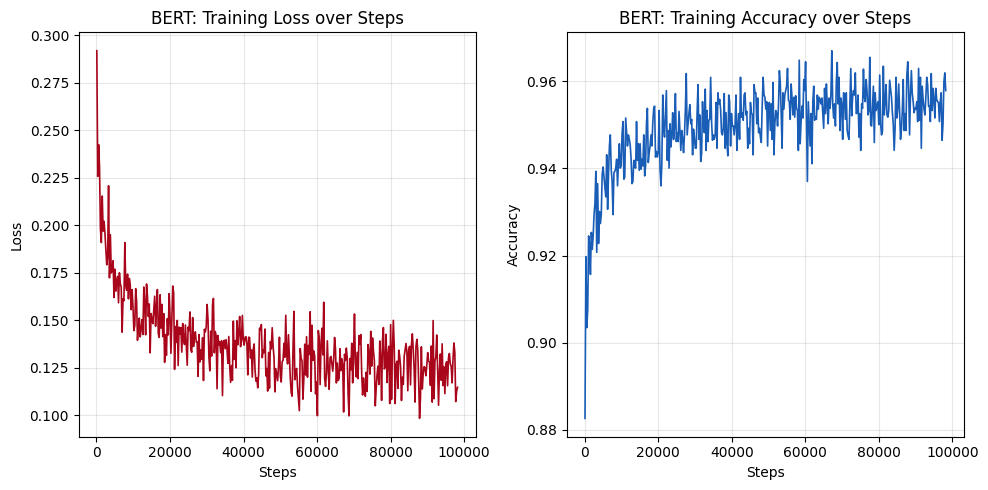

In [10]:
bert.Visualisation(Model_Name="BERT")

In [8]:
# Reload the saved model above
Reload_BERT = bert.Reload_Model(
    base_model="bert-base-uncased",
    model_dir="/mnt/f/Warwick Module/ST415/Code & Dependencies/BERT_Sentiment_Analysis.pt",
    device_selected="cuda")

✅ Reloaded model: Reload_BERT has been loaded


In [9]:
# Test the model on the test set
bert.Test_model(Model=Reload_BERT, Label_mapping={0: "Negative", 1: "Positive", 2: "Gibberish"})

Validating in progress...: 100%|██████████| 50000/50000 [46:13<00:00, 18.03it/s]


,Label,Test_Loss,Test_Acc,Precision,Recall,F1
0,Negative,0.099,0.967,0.949,0.967,0.958
1,Positive,0.137,0.948,0.966,0.948,0.957
2,Gibberish,0.733,0.832,0.949,0.832,0.887
3,Weighted_Total,0.120,0.957,0.957,0.957,0.957


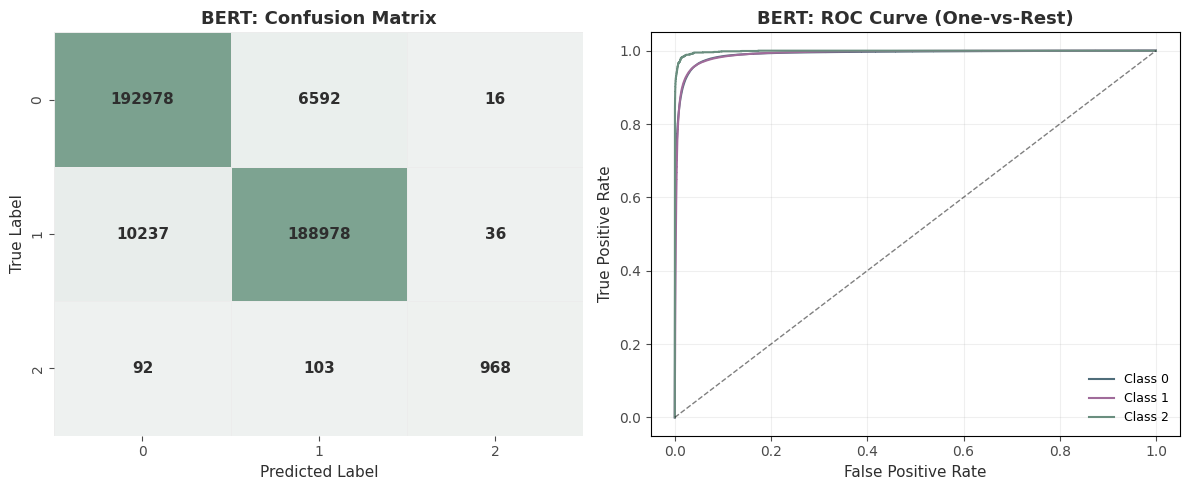

In [11]:
bert.Confusion_matrix_ROC(Model_Name="BERT")

In [12]:
bert.Misclassification(Label_mapping={0: "Negative", 1: "Positive", 2: "Gibberish"})

,Index,True_label,Model_label,Confidence,Text
0,1,Positive,Negative,0.715,My children get easily bored with this video. ...
1,2,Negative,Positive,0.601,This is a great CD!! I love WeiB Kreuz!! The a...
2,3,Positive,Negative,0.703,edith has created a venue for herself to exorc...
3,4,Positive,Negative,0.542,One might notice that many of the negative rev...
4,5,Negative,Positive,0.975,"I have, too, but this isn't it. The translatio..."
...,...,...,...,...,...
17071,17072,Positive,Negative,0.742,"I like low salt, lite salt no salt. So if I am..."
17072,17073,Positive,Negative,0.551,If you are a flowershop owner and searching fo...
17073,17074,Negative,Positive,0.679,"It was not as I expected. It is okay, dont' th..."
17074,17075,Positive,Negative,0.629,There is way too much talking and detailed exp...


In [13]:
# Test the Model
bert.Sentiment_Classification(
    text="qeioudh qwoiuehlkua qwf",
    BERT_Model=Reload_BERT,
    Label_mapping={0: "Negative", 1: "Positive", 2: "Gibberish"})

✨ Final Prediction: Gibberish  |  Confidence = 0.995


In [12]:
summarize_parameters_clean(Sentiment_Model)


=== Parameter Summary (Compact) ===
Layer / Parameter                        | Shape           |    Per-layer |  #Layers |        Total
---------------------------------------------------------------------------------------------------
embeddings.word_embeddings.weight        | (30522, 768)    |            - |        - |   23,440,896
embeddings.position_embeddings.weight    | (512, 768)      |            - |        - |      393,216
embeddings.token_type_embeddings.weight  | (2, 768)        |            - |        - |        1,536
embeddings.LayerNorm.weight              | (768, 1)        |            - |        - |          768
embeddings.LayerNorm.bias                | (768, 1)        |            - |        - |          768
encoder.attention.query.weight           | (768, 768)      |      589,824 |       12 |    7,077,888
encoder.attention.query.bias             | (768, 1)        |          768 |       12 |        9,216
encoder.attention.key.weight             | (768, 768)      |   